# E-commerce Sales & Customer Analytics

### This project aims to analyze e-commerce sales data to identify revenue drivers, profitability issues, and customer purchasing patterns. The analysis focuses on uncovering inefficiencies in pricing and discount strategies, as well as identifying high-value customers to support better business decision-making.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r'C:\Users\hp\Projects\ecommerce-data-analytics-ml\data\Ecommerce_Sales_Data.csv')


In [3]:
df['order_date'] = pd.to_datetime(df['order_date'],dayfirst=True)

## 1. Data Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   order_id       5000 non-null   int64         
 1   order_date     5000 non-null   datetime64[ns]
 2   customer_name  5000 non-null   object        
 3   region         5000 non-null   object        
 4   city           5000 non-null   object        
 5   category       5000 non-null   object        
 6   sub_category   5000 non-null   object        
 7   product_name   5000 non-null   object        
 8   quantity       5000 non-null   int64         
 9   unit_price     5000 non-null   int64         
 10  discount       5000 non-null   int64         
 11  sales          5000 non-null   float64       
 12  profit         5000 non-null   float64       
 13  payment_mode   5000 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(7)
memory usage: 547.

Dataset contains ~5000 records with no missing values  
Key variables: sales, profit, discount

In [5]:
df.isnull().sum()

order_id         0
order_date       0
customer_name    0
region           0
city             0
category         0
sub_category     0
product_name     0
quantity         0
unit_price       0
discount         0
sales            0
profit           0
payment_mode     0
dtype: int64

In [6]:
df.head()

,order_id,order_date,customer_name,region,city,category,sub_category,product_name,quantity,unit_price,discount,sales,profit,payment_mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


## 2. Revenue Analysis

### Total revenue

In [7]:
total_revenue = df['sales'].sum()
total_revenue

np.float64(533666024.35)

Total revenue alone does not indicate performance without profit context → further profitability analysis is required.

### Monthly revenue trend

In [8]:
df['Year_Month'] = df['order_date'].dt.to_period('M')

In [9]:
df.groupby('Year_Month')['sales'].sum().reset_index()

,Year_Month,sales
0,2023-10,21307522.20
1,2023-11,22040269.20
2,2023-12,20624240.25
3,2024-01,21477241.40
4,2024-02,19853396.50
5,2024-03,21571015.35
6,2024-04,22214781.10
7,2024-05,24744786.55
8,2024-06,21368962.50
9,2024-07,24019283.90


It shows monthly revenue and helps tu understand the patterns how the revenue is increasiong or decreasing

### Top 10 products by revenue

In [10]:
df.groupby('product_name')['sales'].sum().sort_values(ascending=False).reset_index().head(10)

,product_name,sales
0,Headphones Accusantium,857184.20
1,Spices Quibusdam,687651.25
2,Accessories Repellendus,687083.30
3,Bed Tenetur,670994.80
4,Laptop Similique,666640.60
5,Lamp Enim,665920.20
6,Shampoo Commodi,659546.60
7,Lamp Veritatis,652909.50
8,Men's Wear Voluptatibus,649048.00
9,Textbook Omnis,633246.25


Are these high profit or just high sales?
Are they concentrated in one category?

In [11]:
df['order_id'].duplicated().sum()

np.int64(0)

In [12]:
df['Month'] = df['order_date'].dt.month

df.head()

### Revenue by category

In [13]:
df.groupby('category')['sales'].sum().reset_index().sort_values(by='sales',ascending = False)

,category,sales
6,Home Decor,57233222.35
4,Furniture,56647187.90
2,Clothing,55053908.30
1,Books,54932643.00
7,Kitchen,54227902.30
3,Electronics,52587883.95
9,Toys,52227366.45
8,Sports,52069397.25
0,Beauty,50803409.70
5,Groceries,47883103.15


### Revenue by region

In [14]:
df.groupby('region')['sales'].sum()

region
East     1.358116e+08
North    1.435782e+08
South    1.232302e+08
West     1.310460e+08
Name: sales, dtype: float64

North region contributes highest revenue → business should prioritize inventory and marketing here.

### Top 5 cities by profit

In [15]:
df.groupby('city')['profit'].sum().sort_values(ascending=False).head()

city
Lucknow       4523681.09
Guwahati      4487271.28
Bangalore     4416914.72
Chandigarh    4375379.60
Jaipur        4353577.84
Name: profit, dtype: float64

## 3. Customer Analysis

### Orders per customer

In [16]:
df.groupby('customer_name')['order_id'].nunique()

customer_name
Aaina Balasubramanian    1
Aaina Bhargava           1
Aaina Bir                1
Aaina Chander            1
Aaina Chandran           1
                        ..
Zoya Loyal               1
Zoya Ranganathan         1
Zoya Reddy               1
Zoya Sami                2
Zoya Sankar              1
Name: order_id, Length: 4844, dtype: int64

### Top 10 customers by revenue

In [17]:
df.groupby('customer_name')['sales'].sum().sort_values(ascending=False).head(10)

customer_name
Aaryahi Madan         650151.9
Kimaya Vala           490935.0
Badal Rao             485698.0
Adira Dhingra         479389.0
Sumer Mann            469937.0
Nayantara Majumdar    459763.5
Prerak Shere          451862.4
Bhamini Sane          441410.6
Samarth Wagle         427715.5
Arhaan Basu           426563.6
Name: sales, dtype: float64

### Percentage of revenue from repeat customers

In [18]:
order_per_customer = df.groupby('customer_name')['order_id'].nunique()
repeat_customer = order_per_customer[order_per_customer > 1].index
repeat_df = df[df['customer_name'].isin(repeat_customer)]
total_revenue = df["sales"].sum()
repeat_revenue = repeat_df["sales"].sum()

In [19]:
repeat_percentage = (repeat_revenue / total_revenue) * 100

In [20]:
repeat_percentage

np.float64(6.3321647918581805)

If repeat customers contribute >60%, retention strategy is critical.

### Monthly revenue line chart

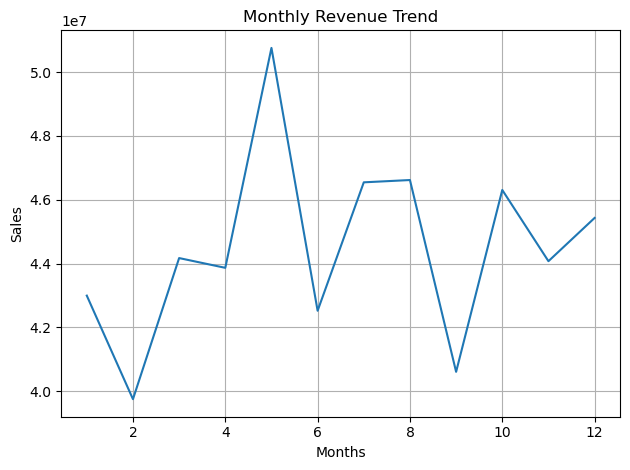

In [21]:
monthly_revenue = df.groupby('Month')['sales'].sum()
monthly_revenue.plot(kind = 'line')
plt.title("Monthly Revenue Trend")
plt.xlabel('Months')
plt.ylabel('Sales')
plt.grid(True)
plt.tight_layout()

The data suggests unstable revenue patterns with a one-time peak in Month 5, indicating potential seasonality or a temporary external factor rather than sustained growth.

### Revenue by category bar chart

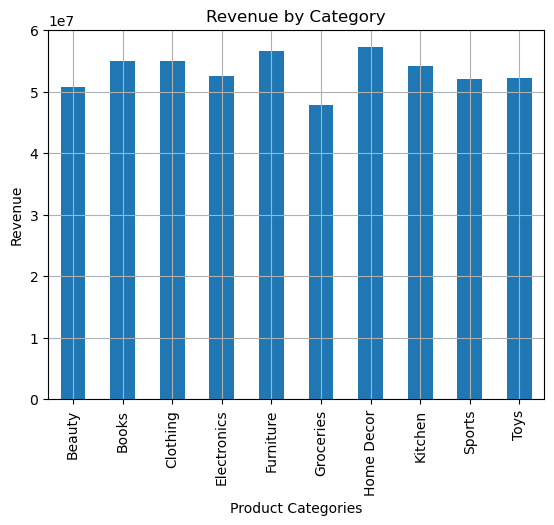

In [22]:
category_revenue = df.groupby('category')['sales'].sum()
category_revenue.plot(kind='bar')
plt.title("Revenue by Category")
plt.xlabel('Product Categories')
plt.ylabel('Revenue')
plt.grid(True)

Revenue distribution across categories is fairly balanced, with no dominant category, though Home Decor slightly leads while Groceries lags behind.

## 4. Profitability Analysis

### Profit by category

In [23]:
profit_by_category = df.groupby('category')['profit'].sum()
profit_by_category

category
Beauty         7213436.07
Books          8076273.29
Clothing       8445750.29
Electronics    8042133.88
Furniture      8693087.03
Groceries      7075332.64
Home Decor     8556846.94
Kitchen        7879573.29
Sports         7739430.04
Toys           7986871.44
Name: profit, dtype: float64

### Profit by sub-category

In [24]:
profit_by_subcategory = df.groupby('sub_category')['profit'].sum()
profit_by_subcategory

sub_category
Accessories      1702232.28
Action Figure    1633699.15
Bed              1852587.47
Biography        1493261.50
Board Game       1516854.41
Cabinet          1605677.82
Camera           1641872.96
Chair            1548661.04
Clock            1571873.38
Comics           1384974.46
Cookware Set     1505782.16
Cricket Bat      1381136.33
Cushion          1417087.93
Doll             1514026.94
Dumbbells        1284166.51
Face Cream       1599375.99
Fiction          1707577.00
Football         1681376.60
Foundation       1352929.62
Headphones       1867457.80
Juicer           1743368.29
Kids Wear        1473426.15
Lamp             2247216.13
Laptop           1495704.86
Lipstick         1482624.68
Men's Wear       1784306.82
Microwave        1333392.21
Mixer Grinder    1700350.95
Mobile           1410292.68
Non-Fiction      1945175.03
Oil              1297003.90
Perfume          1442949.63
Puzzle           1596183.63
RC Car           1726107.31
Refrigerator     1596679.68
Rice   

### Profit margin per category


In [25]:
category_summary = df.groupby("category")[["sales", "profit"]].sum()
category_summary

,sales,profit
category,,
Beauty,50803409.70,7213436.07
Books,54932643.00,8076273.29
Clothing,55053908.30,8445750.29
Electronics,52587883.95,8042133.88
Furniture,56647187.90,8693087.03
Groceries,47883103.15,7075332.64
Home Decor,57233222.35,8556846.94
Kitchen,54227902.30,7879573.29
Sports,52069397.25,7739430.04


In [26]:
category_summary['profit_margin'] = (
    category_summary['profit'] / category_summary['sales']
) * 100

In [27]:
category_summary

,sales,profit,profit_margin
category,,,
Beauty,50803409.70,7213436.07,14.198724
Books,54932643.00,8076273.29,14.702139
Clothing,55053908.30,8445750.29,15.340873
Electronics,52587883.95,8042133.88,15.292750
Furniture,56647187.90,8693087.03,15.346017
Groceries,47883103.15,7075332.64,14.776262
Home Decor,57233222.35,8556846.94,14.950839
Kitchen,54227902.30,7879573.29,14.530478
Sports,52069397.25,7739430.04,14.863683


Categories with high sales but low margin indicate inefficient pricing or high cost.

### Identify products with high sales but low profit

In [28]:
products_summary = df.groupby('product_name')[['sales', 'profit']].sum().reset_index()
products_summary

,product_name,sales,profit
0,Accessories Alias,242285.50,38654.10
1,Accessories Aliquid,10808.00,2068.08
2,Accessories Animi,122584.45,10932.82
3,Accessories Architecto,76115.90,11755.53
4,Accessories Aspernatur,114370.50,17660.94
...,...,...,...
3830,Yoga Mat Vel,46036.00,9505.54
3831,Yoga Mat Velit,76190.60,7521.02
3832,Yoga Mat Vero,96600.60,13506.63
3833,Yoga Mat Voluptate,284205.80,28947.06


In [29]:
high_sales_threshold = products_summary['sales'].quantile(0.75)
low_profit_threshold = products_summary['profit'].quantile(0.25)

In [30]:
problem_product = products_summary[(products_summary['sales'] >= high_sales_threshold) &
    (products_summary['profit'] <= low_profit_threshold)]
problem_product.sort_values("sales", ascending=False).head(10)

,product_name,sales,profit


These products should be reviewed for pricing or cost optimization.

## 5. Discount Impact Analysis

### Average discount per category

In [31]:
avg_discount_per_category = df.groupby('category')['discount'].mean()
avg_discount_per_category

category
Beauty          9.717391
Books           9.867424
Clothing        9.960861
Electronics     9.533898
Furniture      10.132827
Groceries      10.010638
Home Decor     10.252427
Kitchen        10.426136
Sports          9.921722
Toys           10.638075
Name: discount, dtype: float64

The similar profit margins across low and high discount groups suggest that discounting does not significantly impact profitability in this dataset. This may be due to limited variation in discount levels, discounts being applied primarily to high-margin products, or limitations in the dataset where true cost structures are not fully captured

### Correlation between discount and profit

In [32]:
df['discount'].corr(df['profit'])

np.float64(-0.08851620188980272)

Weak correlation suggests discount is not a major driver of profit variation.

In [33]:
df['discount'].describe()

count    5000.000000
mean       10.051000
std         7.084662
min         0.000000
25%         5.000000
50%        10.000000
75%        15.000000
max        20.000000
Name: discount, dtype: float64

In [34]:
low_cut = df['discount'].quantile(0.25)
high_cut = df['discount'].quantile(0.75)

In [35]:
low_discount = df[df['discount'] <= low_cut]
high_discount = df[df['discount'] >= high_cut]

In [36]:
low_margin = (low_discount['profit'].sum()/low_discount['sales'].sum()) * 100
high_margin = (high_discount['profit'].sum()/high_discount['sales'].sum()) * 100

In [37]:
print("Low margin:", low_margin)
print("high margin:", high_margin)

Low margin: 14.976207996500603
high margin: 14.864235665877285


Similar margins indicate pricing power or dataset limitations.

## 6. Key Business Insights

1) Furniture category generates the highest profit among all categories → indicating strong sales performance combined with effective cost management → the business should prioritize inventory and marketing efforts in this category to maximize returns.
2) Furniture also has the highest profit margin, slightly outperforming other categories like Clothing and Electronics → this suggests highly efficient pricing and cost control → scaling this category can significantly improve overall profitability.
3) Repeat customers contribute only ~6.3% of total revenue, indicating that the business relies heavily on new customer acquisition. This suggests weak customer retention, and improving loyalty programs or repeat purchase incentives could help stabilize long-term revenue.
4) Both low-discount and high-discount orders show similar profit margins, indicating that discounting does not significantly impact profitability in this dataset. This may be due to discounts being applied mainly to high-margin products or strong base pricing that absorbs the impact of discounts. However, limited variation in discount levels and simplified profit calculations may reduce the reliability of this observation.
5) Discount levels do not significantly reduce profit margins → indicates strong pricing power or limited discount variation → opportunity to optimize discount strategy further.
6) Revenue varies significantly across regions → certain regions outperform others → marketing and inventory strategies should focus on high-performing regions.